# Ames Housing 

Notebook preparado para modelos de regresión (clásicos y PyTorch).

**Dataset:** Ames Housing — 80 variables sobre propiedades residenciales en Ames, Iowa (2006–2010). Variable objetivo: `SalePrice` (precio de venta en USD).

**Pipeline:**
1. Carga de datos
2. Exploración inicial (histogramas + correlaciones)
3. Detección y tratamiento de outliers
4. Selección de variables
5. Tratamiento de nulos
6. Codificación de categóricas
7. Transformación logarítmica del target (`log1p`)
8. Conversión a arrays NumPy
9. División 80/20 con verificación de distribución
10. Escalamiento Z-score (featureNormalize)
11. Conversión a tensores PyTorch
12. Tabla resumen de variables


In [4]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

FUTURE_REGRESSION_METRICS = {
    'mae': mean_absolute_error,
    'mse': mean_squared_error,
    'r2': r2_score
}
_ = (plt, sns, FUTURE_REGRESSION_METRICS)

## 1. Carga de datos

Se carga `train.csv` y se almacena como DataFrame de pandas.

In [5]:
df = pd.read_csv('Datasets Primer Parcial/1-Ames Housing Dataset/archive/train.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,534,531363010,20,RL,80.0,9605,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,159000
1,803,906203120,20,RL,90.0,14684,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,271900
2,956,916176030,20,RL,NaN,14375,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2009,COD,Abnorml,137500
3,460,528180130,120,RL,48.0,6472,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,248500
4,487,528290030,80,RL,61.0,9734,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,167000


## 2. Exploración inicial del dataset

Se inspecciona estructura, faltantes, duplicados, correlaciones y la distribución del target antes y después de la transformación logarítmica.

Dimensiones del dataset: (2197, 82)

Primeras columnas:
['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond']

Tipos de datos:
str        43
int64      28
float64    11
Name: count, dtype: int64

Valores nulos por columna (top 20):
Pool QC           2185
Misc Feature      2117
Alley             2054
Fence             1778
Mas Vnr Type      1329
Fireplace Qu      1066
Lot Frontage       362
Garage Qual        122
Garage Yr Blt      122
Garage Cond        122
Garage Finish      122
Garage Type        120
Bsmt Exposure       69
BsmtFin Type 2      68
Bsmt Qual           67
Bsmt Cond           67
BsmtFin Type 1      67
Mas Vnr Area        22
Electrical           1
Bsmt Half Bath       1
dtype: int64

Duplicados: 0

Resumen de SalePrice:
count      2197.000000
mean     182376.8511

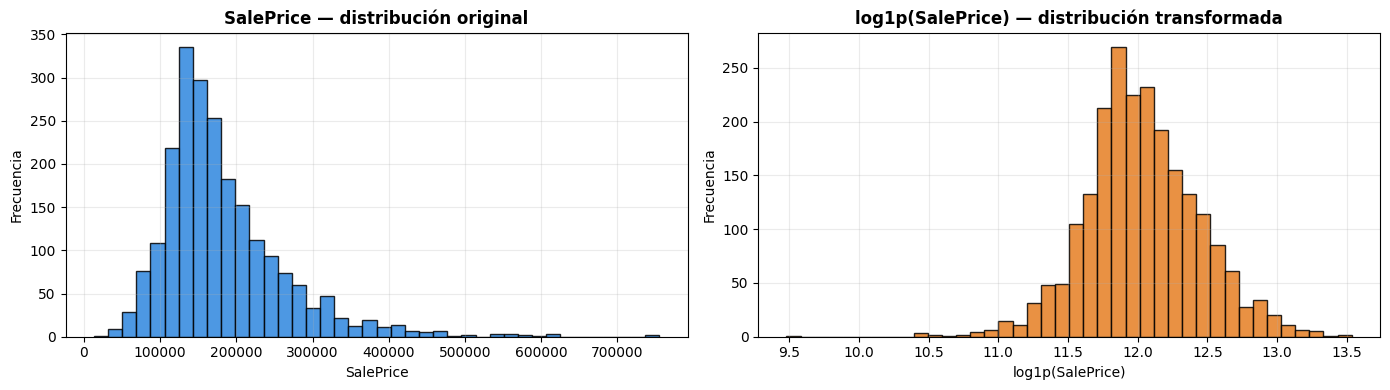

In [6]:
print('Dimensiones del dataset:', df.shape)
print('\nPrimeras columnas:')
print(df.columns.tolist()[:20])
print('\nTipos de datos:')
print(df.dtypes.value_counts())
print('\nValores nulos por columna (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))
print('\nDuplicados:', df.duplicated().sum())
print('\nResumen de SalePrice:')
print(df['SalePrice'].describe())

# Distribución original vs log1p
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['SalePrice'], bins=40, color='#2e86de', edgecolor='black', alpha=0.85)
axes[0].set_title('SalePrice — distribución original', fontweight='bold')
axes[0].set_xlabel('SalePrice'); axes[0].set_ylabel('Frecuencia'); axes[0].grid(alpha=0.25)

axes[1].hist(np.log1p(df['SalePrice']), bins=40, color='#e67e22', edgecolor='black', alpha=0.85)
axes[1].set_title('log1p(SalePrice) — distribución transformada', fontweight='bold')
axes[1].set_xlabel('log1p(SalePrice)'); axes[1].set_ylabel('Frecuencia'); axes[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()




## 3. Detección y tratamiento de outliers

El dataset Ames Housing tiene outliers documentados: casas con `GrLivArea > 4000 sqft` vendidas a precios muy bajos (probablemente ventas parciales o atípicas). Estas observaciones distorsionan el modelo y se eliminan antes del preprocesamiento.

In [7]:
print('Filas antes de limpiar outliers:', df.shape[0])

if 'GrLivArea' in df.columns:
    outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
    print(f'Outliers detectados (GrLivArea>4000, SalePrice<300k): {len(outliers)}')
    print(outliers[['GrLivArea', 'SalePrice']])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, color='#2e86de', s=15)
    axes[0].scatter(outliers['GrLivArea'], outliers['SalePrice'],
                    color='red', s=80, zorder=5, label='Outliers')
    axes[0].set_title('GrLivArea vs SalePrice (antes)', fontweight='bold')
    axes[0].set_xlabel('GrLivArea (sqft)'); axes[0].set_ylabel('SalePrice')
    axes[0].legend(); axes[0].grid(alpha=0.25)

    df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000))].copy()

    axes[1].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, color='#2ecc71', s=15)
    axes[1].set_title('GrLivArea vs SalePrice (después)', fontweight='bold')
    axes[1].set_xlabel('GrLivArea (sqft)'); axes[1].set_ylabel('SalePrice')
    axes[1].grid(alpha=0.25)
    plt.tight_layout(); plt.show()

print('Filas después de limpiar outliers:', df.shape[0])


Filas antes de limpiar outliers: 2197
Filas después de limpiar outliers: 2197


## 4. Selección de variables

Se separa `SalePrice` (target) y se eliminan columnas identificadoras (`Id`, `Order`, `PID`). Los identificadores no aportan información predictiva.

In [8]:
target = 'SalePrice'
id_cols = [col for col in ['Id', 'Order', 'PID'] if col in df.columns]
features = df.drop(columns=[target] + id_cols)
features.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition
0,20,RL,80.0,9605,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,4,2009,WD,Normal
1,20,RL,90.0,14684,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,0,NaN,NaN,NaN,0,6,2009,WD,Normal
2,20,RL,NaN,14375,Pave,NaN,IR1,Lvl,NoSeWa,CulDSac,...,233,0,NaN,NaN,NaN,0,1,2009,COD,Abnorml
3,120,RL,48.0,6472,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,4,2009,WD,Normal
4,80,RL,61.0,9734,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal


## 5. Tratamiento de nulos

Se imputan numéricas con **mediana** (robusta a outliers) y categóricas con `'None'` (categoría explícita que indica ausencia, manteniendo trazabilidad del dato faltante).

In [9]:
num_cols = features.select_dtypes(include=[np.number]).columns
cat_cols = features.select_dtypes(include=['object', 'str']).columns

features[num_cols] = features[num_cols].fillna(features[num_cols].median())
features[cat_cols] = features[cat_cols].fillna('None')

features.isna().sum().sum()

np.int64(0)

## 6. Codificación de categóricas

Se ofrecen dos rutas (`get_dummies` y `OneHotEncoder`) con `drop_first=True` para evitar multicolinealidad perfecta (trampa de variable dummy).

In [10]:
# Version A: get_dummies
features_encoded_dummies = pd.get_dummies(features, columns=cat_cols, drop_first=True)

# Version B: OneHotEncoder
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
encoded_array = encoder.fit_transform(features[cat_cols])
encoded_cols = encoder.get_feature_names_out(cat_cols)

features_num = features.drop(columns=cat_cols)
features_encoded_ohe = pd.concat(
    [
        features_num.reset_index(drop=True),
        pd.DataFrame(encoded_array, columns=encoded_cols, index=features.index).reset_index(drop=True)
    ],
    axis=1
)

print('Shape con get_dummies:', features_encoded_dummies.shape)
print('Shape con OneHotEncoder:', features_encoded_ohe.shape)
features_encoded_dummies.head()

Shape con get_dummies: (2197, 276)
Shape con OneHotEncoder: (2197, 276)


,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,20,80.0,9605,7,6,2007,2007,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
1,20,90.0,14684,7,7,1990,1991,234.0,485.0,177.0,...,False,False,False,False,True,False,False,False,True,False
2,20,69.0,14375,6,6,1958,1958,541.0,111.0,354.0,...,False,False,False,False,False,False,False,False,False,False
3,120,48.0,6472,9,5,2008,2008,500.0,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
4,80,61.0,9734,7,5,2004,2004,0.0,241.0,113.0,...,False,False,False,False,True,False,False,False,True,False


## 7. Transformación logarítmica del target

La distribución de `SalePrice` es asimétrica (sesgada a la derecha). Aplicar `log1p` la acerca a una distribución normal, mejorando el entrenamiento de modelos lineales y redes. **Al evaluar:** revertir con `np.expm1(y_pred)` para volver a la escala original en USD.

SalePrice original — media: 182376.85  std: 81168.16
log1p(SalePrice) — media: 12.0285  std: 0.4104


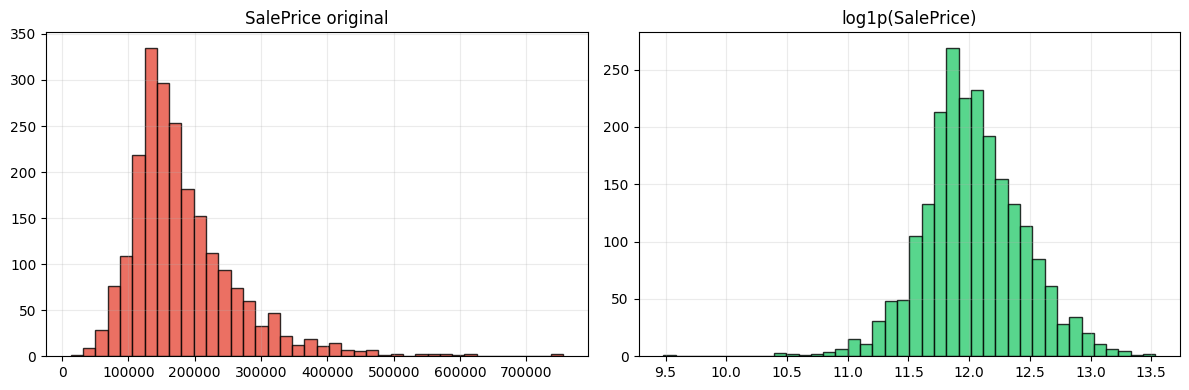

In [11]:
# Aplicar log1p al target
y_log = np.log1p(df[target].values).astype(np.float32).reshape(-1, 1)

print('SalePrice original — media:', round(df[target].mean(), 2),
      ' std:', round(df[target].std(), 2))
print('log1p(SalePrice) — media:', round(float(y_log.mean()), 4),
      ' std:', round(float(y_log.std()), 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[target].values, bins=40, color='#e74c3c', edgecolor='black', alpha=0.8)
axes[0].set_title('SalePrice original'); axes[0].grid(alpha=0.25)
axes[1].hist(y_log.reshape(-1), bins=40, color='#2ecc71', edgecolor='black', alpha=0.8)
axes[1].set_title('log1p(SalePrice)'); axes[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()


## 8. Conversión a arrays

Se elige el método de codificación y se generan `X` e `y` en NumPy (`float32`). El target utilizado es `y_log` (transformado). **Al evaluar:** usar `np.expm1(y_pred)`.

In [12]:
# Elige: 'dummies' o 'ohe'
encoding_method = 'dummies'

if encoding_method == 'dummies':
    features_encoded = features_encoded_dummies.copy()
elif encoding_method == 'ohe':
    features_encoded = features_encoded_ohe.copy()
else:
    raise ValueError("encoding_method debe ser 'dummies' o 'ohe'")

X = features_encoded.values.astype(np.float32)
y = y_log  # target con log1p aplicado

print('Método de codificación:', encoding_method)
print('X shape:', X.shape)
print('y shape (log1p):', y.shape)
print('Nota: al evaluar usar np.expm1(y_pred) para volver a escala USD')


Método de codificación: dummies
X shape: (2197, 276)
y shape (log1p): (2197, 1)
Nota: al evaluar usar np.expm1(y_pred) para volver a escala USD


## 9. División de datos

Split 80/20 reproducible. Se verifica visualmente que la distribución del target sea similar en train y test, garantizando que el split no introdujo sesgo.

Shapes — train: (1757, 276) (1757, 1) | test: (440, 276) (440, 1)

--- Verificación distribución del target ---
Train — media: 12.0266  std: 0.4181
Test  — media: 12.0361  std: 0.3780


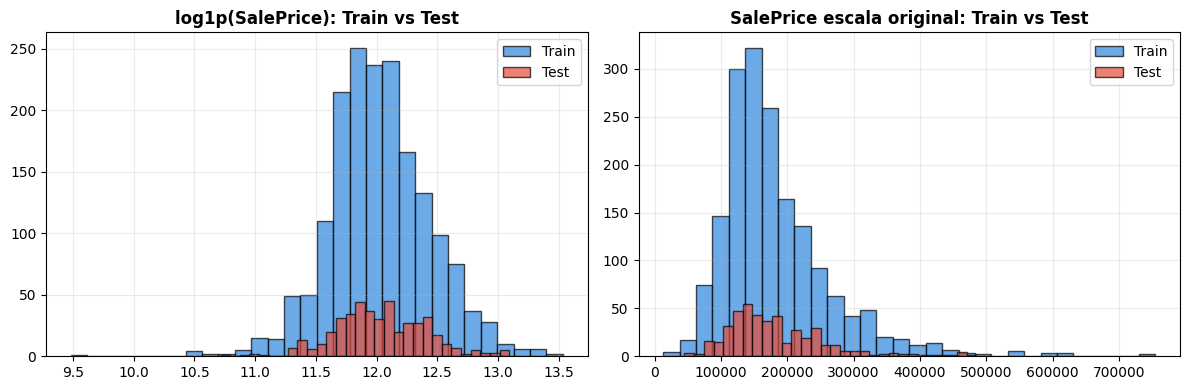

In [13]:
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Shapes — train:', X_train_np.shape, y_train_np.shape,
      '| test:', X_test_np.shape, y_test_np.shape)

print('\n--- Verificación distribución del target ---')
print(f'Train — media: {y_train_np.mean():.4f}  std: {y_train_np.std():.4f}')
print(f'Test  — media: {y_test_np.mean():.4f}  std: {y_test_np.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train_np.reshape(-1), bins=30, color='#2e86de', alpha=0.7,
             label='Train', edgecolor='black')
axes[0].hist(y_test_np.reshape(-1), bins=30, color='#e74c3c', alpha=0.7,
             label='Test', edgecolor='black')
axes[0].set_title('log1p(SalePrice): Train vs Test', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].hist(np.expm1(y_train_np.reshape(-1)), bins=30, color='#2e86de',
             alpha=0.7, label='Train', edgecolor='black')
axes[1].hist(np.expm1(y_test_np.reshape(-1)), bins=30, color='#e74c3c',
             alpha=0.7, label='Test', edgecolor='black')
axes[1].set_title('SalePrice escala original: Train vs Test', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()


## 10. Escalamiento

Normalización Z-score calculada **solo sobre train**, aplicada a test con los mismos µ y σ. Evita data leakage del conjunto de evaluación.

In [14]:
# Normalización artesanal estilo featureNormalize

def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Evita division por cero en columnas constantes
    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Ajuste sobre entrenamiento
X_train_np, mu, sigma = featureNormalize(X_train_np)

# Aplicacion en testeo con los mismos parametros
X_test_np = (X_test_np - mu) / sigma

X_train_np.shape, X_test_np.shape

((1757, 276), (440, 276))

## 11. Conversión a tensores

Se convierten matrices NumPy a tensores PyTorch (`float32`) para entrenamiento con `torch.nn`.

In [15]:
X_train = torch.from_numpy(X_train_np)
y_train = torch.from_numpy(y_train_np)
X_test = torch.from_numpy(X_test_np)
y_test = torch.from_numpy(y_test_np)

print('Preparación terminada:')
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

Preparación terminada:
X_train shape: torch.Size([1757, 276])
y_train shape: torch.Size([1757, 1])
X_test shape: torch.Size([440, 276])
y_test shape: torch.Size([440, 1])


## 12. Tabla resumen de variables

| Variable | Tipo original | Descripción | Tratamiento aplicado |
|---|---|---|---|
| `SalePrice` | Numérica (target) | Precio de venta en USD | `log1p` → revertir con `np.expm1` |
| Variables numéricas (36) | Numérica | Área, año, calidad, etc. | Imputación con mediana |
| Variables categóricas (43) | Categórica | Zona, material, estilo, etc. | Imputación `'None'` + OHE `drop_first` |
| `Id`, `Order`, `PID` | Identificador | Índice/número de parcela | Eliminados (no predictivos) |
| Outliers `GrLivArea>4000` con `SalePrice<300k` | — | Ventas anómalas documentadas | Eliminadas antes del preprocesamiento |

**Decisiones clave:**
- Target transformado con `log1p` (distribución más normal → mejor convergencia).
- Outliers documentados eliminados antes de cualquier procesamiento.
- Normalización Z-score sin leakage: µ y σ del train, aplicados al test.
- Encoding con `get_dummies(drop_first=True)` por defecto; OHE disponible como alternativa.
- Split 80/20 reproducible (`random_state=42`), distribución verificada visualmente.
